# Module 2 Homework — Dataframe Analysis (2026 cohort)

Stock Markets Analytics Zoomcamp · [homework2.md](https://github.com/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/cohorts/2026/homework2.md)

| # | Question | Deliverable |
|---|----------|-------------|
| 1 | Withdrawn IPOs by company type | Company type with the largest total withdrawn value ($M) |
| 2 | Median Sharpe ratio for 2025 IPOs | Median Sharpe as of 2026-09-11 |
| 3 | Fixed-months holding strategy | Optimal holding period (1-12 months) + median growth |
| 4 | RSI < 30 trading strategy | Net income in $ thousands |
| 5 | How to make IPO investing profitable | Open-ended write-up |

**All snapshot dates are hard-coded** (`2026-09-11`, `2025-09-01`, ...) so the notebook stays reproducible:
the answers to submit are the values printed by the `ANSWER` cells.

> Run order matters: Q3 reuses `stocks_df` built in Q2.

In [1]:
# Colab / fresh environment setup - skip locally if these are already installed
# !pip install -q yfinance pandas numpy matplotlib gdown pyarrow lxml html5lib

In [2]:
import warnings
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"
    )
}

# Snapshot dates used throughout the homework
SNAPSHOT_DATE = "2026-09-11"     # "today" for Q1/Q2
IPO_CUTOFF_DATE = "2025-09-01"   # Q2: IPOs priced before this date

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.3


In [3]:
def read_html_tables(url: str) -> list:
    """pandas.read_html with a browser User-Agent (iposcoop blocks the default one)."""
    response = requests.get(url, headers=HEADERS, timeout=60)
    response.raise_for_status()
    return pd.read_html(StringIO(response.text))

---
## Question 1 - [IPO] Withdrawn IPOs by company type

**Which company class has the highest total withdrawn IPO value (in $ millions)?**

Plan:

1. Load the *Recently Filed IPOs* table and keep rows where `Expected To Trade == 'Withdrawn'` (expect **32 rows**).
2. Tag each company with a **Company Type** from its name - *order matters*, first match wins.
3. Parse `Price Low` / `Price High` into a numeric **Avg_price**.
4. Clean `Shares (millions)` and `Est $ Vol (millions)` into numbers.
5. **Shares_offered_value** = `Shares x Avg_price`, falling back to `Est $ Vol` when that product is null.
6. Group by company type and sum.

> Quirk worth knowing: because `"corp"` is checked before `"inc"`, the substring in *In**corp**orated*
> matches the Acquisition Corp rule first. That is what the homework's stated order produces, so the
> code follows it literally rather than "fixing" it.

In [4]:
IPO_FILED_URL = "https://www.iposcoop.com/ipos-recently-filed/"

tables = read_html_tables(IPO_FILED_URL)
print(f"{len(tables)} table(s) found on the page")

filed_df = max(tables, key=len).copy()   # the IPO table is by far the largest
filed_df.columns = [str(c).strip() for c in filed_df.columns]
print("shape:", filed_df.shape)
print("columns:", list(filed_df.columns))
filed_df.head()

1 table(s) found on the page
shape: (500, 10)
columns: ['File Date', 'Company', 'Symbol', 'Managers', 'Shares (millions)', 'Price Low', 'Price High', 'Est $ Vol (millions)', 'Expected To Trade', 'SCOOP Rating']


,File Date,Company,Symbol,Managers,Shares (millions),Price Low,Price High,Est $ Vol (millions),Expected To Trade,SCOOP Rating
0,2026-09-14,ADARx Pharmaceuticals,ADRX,J.P.Morgan/Morgan Stanley/TD Cowen/UBS Investm...,0.0000,NaN,NaN,$100.00,TBA,S/O
1,2026-09-14,Bamboo Insurance Services,BMB,J.P.Morgan/Morgan Stanley/Deutsche Bank Securi...,35.0000,$18.00,$20.00,$665.00,Wednesday,S/O
2,2026-09-14,Electra Therapeutics,ETRA,Jefferies/TD Cowen/Evercore ISI/Cantor,21.6700,$14.00,$16.00,$325.05,Friday,S/O
3,2026-09-11,Accelevation Holdings Corp.,ACCV,Morgan Stanley/J.P. Morgan/Goldman Sachs/Barcl...,0.0000,NaN,NaN,$100.00,TBA,S/O
4,2026-09-10,Allarity Acquisition Corp.,ALLNU,Maxim Group,10.0000,$10.00,$10.00,$100.00,TBA,S/O


In [5]:
# Step 1 - keep only withdrawn deals
status_col = next(c for c in filed_df.columns if "expected" in c.lower())
print("status column:", repr(status_col))

withdrawn_df = filed_df[
    filed_df[status_col].astype(str).str.strip().str.lower() == "withdrawn"
].copy()

print(f"Withdrawn entries: {len(withdrawn_df)}  (homework expects 32)")
withdrawn_df.head()

status column: 'Expected To Trade'
Withdrawn entries: 32  (homework expects 32)


,File Date,Company,Symbol,Managers,Shares (millions),Price Low,Price High,Est $ Vol (millions),Expected To Trade,SCOOP Rating
5,2026-09-10,Motive Technologies (Withdrawn),MTVE,J.P.Morgan/Citigroup/Barclays/Jefferies/RBC Ca...,0.0000,NaN,NaN,$100.00,Withdrawn,S/O
12,2026-09-04,Idea Tech Holding (Withdrawn),IDTL,R.F. Lafferty & Co.,2.0000,$4.00,$5.00,$9.00,Withdrawn,S/O
21,2026-09-01,Hornbeck Offshore Services (Withdrawn),HOS,J.P. Morgan/ Barclays/DNB Markets/Piper Sandle...,0.0000,NaN,NaN,$100.00,Withdrawn,S/O
23,2026-08-31,Coolbit Technologies Ltd. (Withdrawn),CBAI,Eddid Securities USA,5.0000,$4.00,$5.00,$22.50,Withdrawn,S/O
32,2026-08-27,Timber Road Acquisition Corp. (Withdrawn),TMRDU,Roth Capital Partners/Stone X Financial Inc.,20.0000,$10.00,$10.00,$200.00,Withdrawn,S/O


In [6]:
# Step 2 - classify the company name. ORDER MATTERS: the first pattern that matches wins.
COMPANY_TYPE_RULES = [
    ("Technologies", ["technologies"]),
    ("Acquisition Corp", ["acquisition corp", "acquisition corporation", "corp"]),
    ("Inc.", ["inc", "incorporated"]),
    ("Group", ["group"]),
    ("Limited", ["ltd", "limited"]),
    ("Holdings", ["holdings", "holding"]),
]


def classify_company(name: str) -> str:
    """Map a company name to one of the homework's company types."""
    text = str(name).lower()
    for label, patterns in COMPANY_TYPE_RULES:
        if any(pattern in text for pattern in patterns):
            return label
    return "Other"


company_col = next(c for c in withdrawn_df.columns if "company" in c.lower())
withdrawn_df["Company Type"] = withdrawn_df[company_col].apply(classify_company)
withdrawn_df["Company Type"].value_counts()

Company Type
Other               8
Limited             8
Acquisition Corp    5
Holdings            4
Technologies        3
Group               3
Inc.                1
Name: count, dtype: int64

In [7]:
# Step 3 - parse prices
def parse_price(value) -> float:
    """'$8.00' -> 8.0 ; '-' / '' / NaN -> NaN. Also survives ranges like '$8.00-$10.00'."""
    if pd.isna(value):
        return np.nan
    text = str(value).replace("$", "").replace(",", "").strip()
    if text.lower() in {"", "-", "--", "n/a", "tbd", "nan"}:
        return np.nan
    parts = pd.Series(text.replace("\u2013", "-").split("-")).str.strip()
    numbers = pd.to_numeric(parts, errors="coerce").dropna()
    return float(numbers.mean()) if len(numbers) else np.nan


withdrawn_df["Price_low_num"] = withdrawn_df["Price Low"].apply(parse_price)
withdrawn_df["Price_high_num"] = withdrawn_df["Price High"].apply(parse_price)
withdrawn_df["Avg_price"] = withdrawn_df[["Price_low_num", "Price_high_num"]].mean(axis=1)

print("Avg_price non-null:", withdrawn_df["Avg_price"].notna().sum(), "of", len(withdrawn_df))
withdrawn_df[[company_col, "Price Low", "Price High", "Avg_price"]].head(10)

Avg_price non-null: 26 of 32


,Company,Price Low,Price High,Avg_price
5,Motive Technologies (Withdrawn),NaN,NaN,NaN
12,Idea Tech Holding (Withdrawn),$4.00,$5.00,4.5000
21,Hornbeck Offshore Services (Withdrawn),NaN,NaN,NaN
23,Coolbit Technologies Ltd. (Withdrawn),$4.00,$5.00,4.5000
32,Timber Road Acquisition Corp. (Withdrawn),$10.00,$10.00,10.0000
45,pan-Africa Corp. (Withdrawn),$10.00,$10.00,10.0000
61,Living Homeopathy (Withdrawn),$4.00,$6.00,5.0000
105,Nuclea Energy (Withdrawn),$8.00,$10.00,9.0000
136,APEX Global Solutions Ltd. (WITHDRAWN),$4.00,$4.00,4.0000
141,Cloud Data Holdings (Withdrawn),$4.00,$4.50,4.2500


In [8]:
# Step 4 - numeric conversion for shares and estimated volume
def to_number(value) -> float:
    """Strip $ and thousands separators, then convert to float ('-' -> NaN)."""
    if pd.isna(value):
        return np.nan
    text = str(value).replace("$", "").replace(",", "").strip()
    if text.lower() in {"", "-", "--", "n/a", "nan"}:
        return np.nan
    return pd.to_numeric(text, errors="coerce")


shares_col = next(c for c in withdrawn_df.columns if c.lower().startswith("shares"))
vol_col = next(c for c in withdrawn_df.columns if "vol" in c.lower())
print("shares column:", repr(shares_col), "| volume column:", repr(vol_col))

withdrawn_df["Shares_num"] = withdrawn_df[shares_col].apply(to_number)
withdrawn_df["Est_vol_num"] = withdrawn_df[vol_col].apply(to_number)

withdrawn_df[[shares_col, "Shares_num", vol_col, "Est_vol_num"]].head()

shares column: 'Shares (millions)' | volume column: 'Est $ Vol (millions)'


,Shares (millions),Shares_num,Est $ Vol (millions),Est_vol_num
5,0.0000,0.0000,$100.00,100.0000
12,2.0000,2.0000,$9.00,9.0000
21,0.0000,0.0000,$100.00,100.0000
23,5.0000,5.0000,$22.50,22.5000
32,20.0000,20.0000,$200.00,200.0000


In [9]:
# Step 5 - Shares_offered_value: shares x price, else the estimated $ volume
product = withdrawn_df["Shares_num"] * withdrawn_df["Avg_price"]
withdrawn_df["Shares_offered_value"] = product.fillna(withdrawn_df["Est_vol_num"])

print("from shares x price :", product.notna().sum())
print("fallback to Est $Vol:", (product.isna() & withdrawn_df["Est_vol_num"].notna()).sum())
print("still missing       :", withdrawn_df["Shares_offered_value"].isna().sum())

withdrawn_df[[company_col, "Company Type", "Shares_num", "Avg_price",
              "Est_vol_num", "Shares_offered_value"]]

from shares x price : 26
fallback to Est $Vol: 6
still missing       : 0


,Company,Company Type,Shares_num,Avg_price,Est_vol_num,Shares_offered_value
5,Motive Technologies (Withdrawn),Technologies,0.0000,NaN,100.0000,100.0000
12,Idea Tech Holding (Withdrawn),Holdings,2.0000,4.5000,9.0000,9.0000
21,Hornbeck Offshore Services (Withdrawn),Other,0.0000,NaN,100.0000,100.0000
23,Coolbit Technologies Ltd. (Withdrawn),Technologies,5.0000,4.5000,22.5000,22.5000
32,Timber Road Acquisition Corp. (Withdrawn),Acquisition Corp,20.0000,10.0000,200.0000,200.0000
45,pan-Africa Corp. (Withdrawn),Acquisition Corp,12.5000,10.0000,125.0000,125.0000
61,Living Homeopathy (Withdrawn),Other,3.7500,5.0000,19.0000,18.7500
105,Nuclea Energy (Withdrawn),Other,5.6000,9.0000,50.4000,50.4000
136,APEX Global Solutions Ltd. (WITHDRAWN),Limited,3.7500,4.0000,15.0000,15.0000
141,Cloud Data Holdings (Withdrawn),Holdings,3.7500,4.2500,15.9400,15.9375


In [10]:
# Step 6 - aggregate
q1_summary = (
    withdrawn_df.groupby("Company Type")["Shares_offered_value"]
    .agg(total_value_musd="sum", deals="count")
    .sort_values("total_value_musd", ascending=False)
)
q1_summary

,total_value_musd,deals
Company Type,,
Acquisition Corp,499.9850,5
Inc.,351.0000,1
Holdings,311.6575,4
Other,290.4450,8
Limited,203.8500,8
Technologies,184.9000,3
Group,32.5000,3


In [11]:
q1_type = q1_summary["total_value_musd"].idxmax()
q1_value = q1_summary["total_value_musd"].max()

print("ANSWER Q1")
print(f"  Company type with the largest withdrawn value : {q1_type}")
print(f"  Total withdrawn value                         : ${q1_value:,.1f}M  (~${q1_value/1000:,.2f}B)")

ANSWER Q1
  Company type with the largest withdrawn value : Acquisition Corp
  Total withdrawn value                         : $500.0M  (~$0.50B)


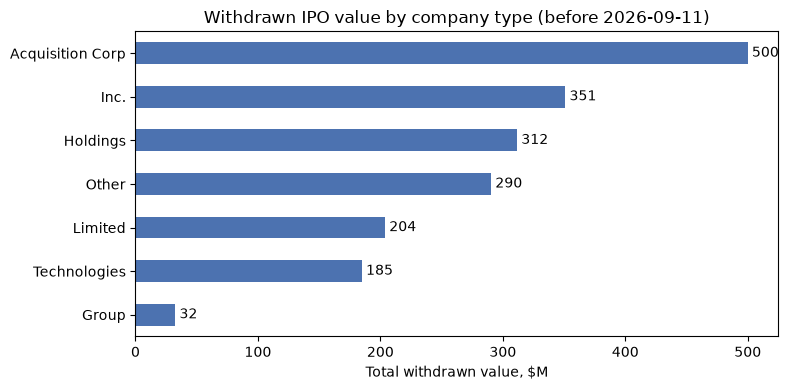

In [12]:
# Optional: where the withdrawn money sat
ax = q1_summary["total_value_musd"].sort_values().plot(
    kind="barh", figsize=(8, 4), color="#4C72B0"
)
ax.set_xlabel("Total withdrawn value, $M")
ax.set_ylabel("")
ax.set_title("Withdrawn IPO value by company type (before 2026-09-11)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

---
## Question 2 - [IPO] Median Sharpe ratio for 2025 IPOs (first 8 months)

**What is the median Sharpe ratio on 2026-09-11 for companies that went public before 2025-09-01?**

Plan:

1. Load the 2025 pricings table (231 IPOs).
2. Keep `Offer Date < 2025-09-01` and drop rows with a 0% return (dead/delisted tickers) -> **148 stocks**.
3. Download daily OHLCV with `yfinance`, skipping tickers Yahoo doesn't know -> **~134 stocks**.
4. `growth_252d = Close / Close.shift(252)`, `volatility = Close.rolling(30).std() * sqrt(252)`.
5. `Sharpe = (growth_252d - 0.05) / volatility`, risk-free rate 5%.
6. Slice the snapshot date and `describe()`.

Note on the formula: `growth_252d` is a *ratio* (~1.2 for +20%) while volatility is in *price units*,
so this "Sharpe" is the course's simplified version, not the textbook one - fine for ranking, odd in absolute terms.

In [13]:
IPO_2025_URL = "https://www.iposcoop.com/2025-pricings/"

tables_2025 = read_html_tables(IPO_2025_URL)
ipos_2025 = max(tables_2025, key=len).copy()
ipos_2025.columns = [str(c).strip() for c in ipos_2025.columns]

print("shape:", ipos_2025.shape, "(homework expects 231 rows)")
print("columns:", list(ipos_2025.columns))
ipos_2025.head()

shape: (231, 10) (homework expects 231 rows)
columns: ['Company', 'Symbol', 'Industry', 'Offer Date', 'Shares (millions)', 'Offer Price', '1st Day Close', 'Current Price', 'Return', 'SCOOP Rating']


,Company,Symbol,Industry,Offer Date,Shares (millions),Offer Price,1st Day Close,Current Price,Return,SCOOP Rating
0,Vine Hill Capital Investment Corp. II,VHCPU,Blank Check,12/18/2025,20.0000,$10.00,$0.00,$0.00,0.00%,S/O
1,Andersen Group,ANDG,Consumer Services,12/17/2025,11.0000,$16.00,$23.50,$23.79,48.69%,S/O
2,Medline Inc.,MDLN,Health Care,12/17/2025,216.0000,$29.00,$41.00,$43.83,51.14%,S/O
3,Wealthfront Corp.,WLTH,Financials,12/12/2025,34.6000,$14.00,$14.19,$8.49,-39.36%,S/O
4,Lumexa Imaging Holdings,LMRI,Health Care,12/11/2025,25.0000,$18.50,$18.52,$14.80,-20.00%,S/O


In [14]:
# Step 2 - filter by offer date and drop 0% returns
date_col = next(c for c in ipos_2025.columns if "date" in c.lower())
return_col = next(c for c in ipos_2025.columns if "return" in c.lower())
symbol_col = next(c for c in ipos_2025.columns if "symbol" in c.lower() or "ticker" in c.lower())
name_col = next(c for c in ipos_2025.columns if "company" in c.lower() or "issuer" in c.lower())
print(f"date={date_col!r} return={return_col!r} symbol={symbol_col!r}")

ipos_2025["Offer_date"] = pd.to_datetime(ipos_2025[date_col], errors="coerce")
ipos_2025["Return_pct"] = pd.to_numeric(
    ipos_2025[return_col].astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False),
    errors="coerce",
)

filtered_ipos = ipos_2025[
    (ipos_2025["Offer_date"] < IPO_CUTOFF_DATE)
    & (ipos_2025["Return_pct"].fillna(0) != 0)
].copy()

filtered_ipos["Ticker"] = filtered_ipos[symbol_col].astype(str).str.strip().str.upper()
TICKERS = sorted(filtered_ipos["Ticker"].unique())

print(f"IPOs before {IPO_CUTOFF_DATE} with non-zero return: {len(filtered_ipos)}  (homework expects 148)")
print(f"unique tickers: {len(TICKERS)}")
filtered_ipos[[name_col, "Ticker", "Offer_date", "Return_pct"]].head()

date='Offer Date' return='Return' symbol='Symbol'
IPOs before 2025-09-01 with non-zero return: 146  (homework expects 148)
unique tickers: 146


,Company,Ticker,Offer_date,Return_pct
68,"Picard Medical, Inc.",PMI,2025-08-29,-58.0000
69,GrowHub Limited (The),TGHL,2025-08-28,-90.0000
70,TryHard Holdings Limited,THH,2025-08-28,636.7500
71,Curanex Pharmaceuticals,CURX,2025-08-26,-90.7500
72,"Cantor Equity Partners IV, Inc. (Stock-Only SPAC)",CEPF,2025-08-21,1.2000


In [15]:
import yfinance as yf


def download_one(ticker: str):
    """Full daily history for one ticker; None when Yahoo has nothing (likely delisted)."""
    try:
        prices = yf.Ticker(ticker).history(period="max", interval="1d", auto_adjust=False)
        if prices is None or prices.empty:
            return None
        prices = prices.copy()
        # yfinance usually returns a tz-aware index, but not always - calling
        # tz_localize(None) on an already-naive index raises, so check first.
        index = pd.to_datetime(prices.index)
        if getattr(index, "tz", None) is not None:
            index = index.tz_localize(None)
        prices.index = index
        prices["Ticker"] = ticker
        prices["Date"] = prices.index
        return prices.reset_index(drop=True)
    except Exception as exc:                      # network hiccup, bad symbol, ...
        print(f"  {ticker}: skipped ({type(exc).__name__}: {exc})")
        return None

In [16]:
# Steps 3 + 4 - download and engineer features per ticker
RISK_FREE_RATE = 0.05

frames, missing = [], []
for i, ticker in enumerate(TICKERS, start=1):
    prices = download_one(ticker)
    if prices is None:
        missing.append(ticker)
        continue

    # historical growth over ~1 trading year
    prices["growth_252d"] = prices["Close"] / prices["Close"].shift(252)
    # annualized volatility - homework formula (rolling std of PRICES, not of returns)
    prices["volatility"] = prices["Close"].rolling(30).std() * np.sqrt(252)
    # A perfectly flat 30-day window (a SPAC pegged at $10.00, or a halted ticker)
    # gives volatility == 0, which would make Sharpe +/-inf. An infinite
    # risk-adjusted return is not a real observation - mark it undefined instead,
    # otherwise it poisons describe()'s mean/max and breaks the histograms.
    prices.loc[prices["volatility"] == 0, "volatility"] = np.nan
    # simplified Sharpe ratio
    prices["Sharpe"] = (prices["growth_252d"] - RISK_FREE_RATE) / prices["volatility"]

    frames.append(prices)
    if i % 25 == 0:
        print(f"  ...{i}/{len(TICKERS)} processed")

if not frames:
    raise RuntimeError("No tickers downloaded - check the network or the ticker list.")

stocks_df = pd.concat(frames, ignore_index=True)
# belt and braces: no infinities anywhere in the engineered columns
stocks_df[["growth_252d", "volatility", "Sharpe"]] = (
    stocks_df[["growth_252d", "volatility", "Sharpe"]].replace([np.inf, -np.inf], np.nan)
)

print(f"\ntickers downloaded : {stocks_df['Ticker'].nunique()}  (homework expects ~134)")
print(f"tickers missing    : {len(missing)} -> {missing}")
print(f"rows               : {len(stocks_df):,}")
stocks_df.tail(3)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AGH"}}}
$AGH: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AHL"}}}
$AHL: possibly delisted; no timezone found
$CAEP: possibly delisted; no timezone found


  ...25/146 processed


$CEPT: possibly delisted; no timezone found
$EMPG: possibly delisted; no timezone found


  ...50/146 processed


$EPWK: possibly delisted; no timezone found


...

$MCTR: possibly delisted; no timezone found
$MJID: possibly delisted; no timezone found
$MTSR: possibly delisted; no timezone found


  ...100/146 processed


$PTNM: possibly delisted; no timezone found
$SDM: possibly delisted; no timezone found
$SKBL: possibly delisted; no timezone found
$TBH: possibly delisted; no timezone found


  ...125/146 processed

tickers downloaded : 133  (homework expects ~134)
tickers missing    : 13 -> ['AGH', 'AHL', 'CAEP', 'CEPT', 'EMPG', 'EPWK', 'MCTR', 'MJID', 'MTSR', 'PTNM', 'SDM', 'SKBL', 'TBH']
rows               : 66,661


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Ticker,Date,growth_252d,volatility,Sharpe,Capital Gains
66658,1.5500,1.6200,1.5500,1.5500,1.5500,22400,0.0000,0.0000,ZYBT,2026-09-11,0.1490,3.7347,0.0265,NaN
66659,1.5500,1.5500,1.4000,1.4200,1.4200,55300,0.0000,0.0000,ZYBT,2026-09-14,0.1542,3.6667,0.0284,NaN
66660,1.4100,1.4100,1.3600,1.3800,1.3800,27800,0.0000,0.0000,ZYBT,2026-09-15,0.1481,3.6257,0.0270,NaN


In [17]:
# Cache so Q3 can be re-run without re-downloading
stocks_df.to_parquet("stocks_df_ipo2025.parquet", index=False)
# stocks_df = pd.read_parquet("stocks_df_ipo2025.parquet")   # <- uncomment to reload
print("cached to stocks_df_ipo2025.parquet")

cached to stocks_df_ipo2025.parquet


In [18]:
# Steps 5 + 6 - snapshot on 2026-09-11
snapshot_df = stocks_df[stocks_df["Date"].dt.normalize() == pd.Timestamp(SNAPSHOT_DATE)]

print(f"stocks trading on {SNAPSHOT_DATE}: {len(snapshot_df)}")
print(f"  of which with a defined Sharpe: {int(snapshot_df['Sharpe'].notna().sum())}"
      f"  (the rest lack 252 days of history, or had a flat 30-day window)")
snapshot_df[["growth_252d", "volatility", "Sharpe"]].describe()

stocks trading on 2026-09-11: 131
  of which with a defined Sharpe: 127  (the rest lack 252 days of history, or had a flat 30-day window)


,growth_252d,volatility,Sharpe
count,129.0000,127.0000,127.0000
mean,1.0602,23.4979,"33,108.4625"
std,3.0597,41.4742,"373,111.3227"
min,0.0010,0.0000,-0.0401
25%,0.1490,2.3771,0.0121
50%,0.5960,8.3589,0.0480
75%,1.0402,23.9685,0.1264
max,33.6383,276.4241,"4,204,751.2505"


In [19]:
q2_median_sharpe = snapshot_df["Sharpe"].median()
q2_median_growth = snapshot_df["growth_252d"].median()
q2_mean_growth = snapshot_df["growth_252d"].mean()
q2_count = int(snapshot_df["growth_252d"].notna().sum())

print("ANSWER Q2")
print(f"  Median Sharpe ratio on {SNAPSHOT_DATE} : {q2_median_sharpe:.3f}  (rounded: {q2_median_sharpe:.2f})")
print()
print(f"  stocks that reached the 252-day mark  : {q2_count}")
print(f"  median growth_252d                    : {q2_median_growth:.3f}  ({(q2_median_growth-1)*100:+.1f}%)")
print(f"  mean   growth_252d                    : {q2_mean_growth:.3f}  ({(q2_mean_growth-1)*100:+.1f}%)")
print("  -> mean >> median means a handful of winners drag the average up;")
print("     the typical 2025 IPO did far worse than the average suggests.")

ANSWER Q2
  Median Sharpe ratio on 2026-09-11 : 0.048  (rounded: 0.05)

  stocks that reached the 252-day mark  : 129
  median growth_252d                    : 0.596  (-40.4%)
  mean   growth_252d                    : 1.060  (+6.0%)
  -> mean >> median means a handful of winners drag the average up;
     the typical 2025 IPO did far worse than the average suggests.


In [20]:
# Best and worst risk-adjusted names on the snapshot date
cols = ["Ticker", "Close", "growth_252d", "volatility", "Sharpe"]
ranked = snapshot_df[cols].dropna(subset=["Sharpe"]).sort_values("Sharpe", ascending=False)
print("Top 10 by Sharpe:")
display(ranked.head(10))
print("Bottom 10 by Sharpe:")
display(ranked.tail(10))

Top 10 by Sharpe:


,Ticker,Close,growth_252d,volatility,Sharpe
43943,MAGH,6.7600,5.4516,0.0000,"4,204,751.2505"
37675,HCMAU,10.4700,1.0346,0.1828,5.3853
24399,CEPF,10.3550,1.0242,0.3516,2.7710
60974,TMDE,0.7490,0.7762,0.4147,1.7512
60621,TLIH,5.7500,0.9897,0.6485,1.4489
24822,CEPO,10.7550,1.0312,0.7953,1.2338
39055,HXHX,0.4710,0.4096,0.4774,0.7532
35399,FBGL,0.3750,0.5769,0.8380,0.6288
34635,ETS,1.5000,1.5593,2.8684,0.5262
30434,CTW,2.3400,1.1642,2.5904,0.4301


Bottom 10 by Sharpe:


,Ticker,Close,growth_252d,volatility,Sharpe
48034,MSGY,2.0800,0.0198,6.2638,-0.0048
47404,MIMI,0.9690,0.0108,7.8851,-0.0050
46128,MENS,1.9900,0.0361,1.8518,-0.0075
13764,BIYA,2.2200,0.0132,4.7426,-0.0078
55928,PPCB,0.9210,0.0213,3.6732,-0.0078
31775,DGNX,1.3700,0.0162,2.4091,-0.0140
59794,TDIC,2.2500,0.0047,3.1624,-0.0143
34030,EPSM,1.3600,0.0337,1.0238,-0.0160
36685,FMFC,0.1980,0.0183,1.0010,-0.0317
43668,LZMH,1.2600,0.0177,0.8034,-0.0401


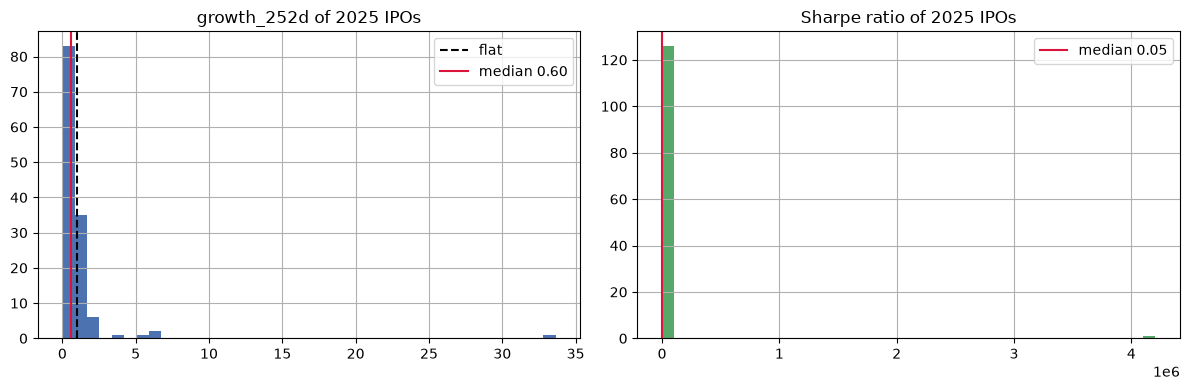

In [21]:
def finite(series: pd.Series) -> pd.Series:
    """Values matplotlib can bin: no NaN, no +/-inf."""
    return series.replace([np.inf, -np.inf], np.nan).dropna()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

finite(snapshot_df["growth_252d"]).hist(bins=40, ax=axes[0], color="#4C72B0")
axes[0].axvline(1, color="black", linestyle="--", label="flat")
axes[0].axvline(q2_median_growth, color="crimson", label=f"median {q2_median_growth:.2f}")
axes[0].set_title("growth_252d of 2025 IPOs")
axes[0].legend()

finite(snapshot_df["Sharpe"]).hist(bins=40, ax=axes[1], color="#55A868")
axes[1].axvline(q2_median_sharpe, color="crimson", label=f"median {q2_median_sharpe:.2f}")
axes[1].set_title("Sharpe ratio of 2025 IPOs")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Question 3 - [IPO] Fixed months holding strategy

**Buying at the first close and holding N months (N = 1...12) - which N maximises the median growth?**

Plan:

1. Reuse `stocks_df` from Q2.
2. Add `future_growth_1_m ... future_growth_12_m`, where *1 month = 21 trading days*:
   `Close.shift(-21*k) / Close` **computed per ticker** (otherwise the shift leaks across tickers).
3. Find each ticker's first trading day (`min_date`).
4. Inner-join those first days back onto the growth table -> one row per IPO.
5. `describe()` the 12 columns and read off the highest 50th percentile.

In [22]:
# Step 2 - 12 fixed-horizon future growth columns, computed within each ticker
TRADING_DAYS_PER_MONTH = 21
growth_cols = []

stocks_df = stocks_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
grouped_close = stocks_df.groupby("Ticker")["Close"]

for month in range(1, 13):
    col = f"future_growth_{month}_m"
    horizon = TRADING_DAYS_PER_MONTH * month
    stocks_df[col] = grouped_close.shift(-horizon) / stocks_df["Close"]
    growth_cols.append(col)

print("created:", growth_cols)
stocks_df[["Ticker", "Date", "Close"] + growth_cols].head(3)

created: ['future_growth_1_m', 'future_growth_2_m', 'future_growth_3_m', 'future_growth_4_m', 'future_growth_5_m', 'future_growth_6_m', 'future_growth_7_m', 'future_growth_8_m', 'future_growth_9_m', 'future_growth_10_m', 'future_growth_11_m', 'future_growth_12_m']


,Ticker,Date,Close,future_growth_1_m,future_growth_2_m,future_growth_3_m,future_growth_4_m,future_growth_5_m,future_growth_6_m,future_growth_7_m,future_growth_8_m,future_growth_9_m,future_growth_10_m,future_growth_11_m,future_growth_12_m
0,AAPG,2025-01-24,17.3800,1.1600,1.0570,1.5129,1.4853,2.3481,2.2595,2.4594,2.1766,2.0403,1.8429,1.6041,1.4724
1,AAPG,2025-01-27,17.2500,1.1983,1.1710,1.4661,1.4160,2.2957,2.3235,2.4000,2.1641,2.0035,1.8765,1.6046,1.4667
2,AAPG,2025-01-28,17.2000,1.1512,1.2587,1.4070,1.4738,2.2892,2.1802,2.3915,2.2413,1.9477,1.8674,1.5070,1.4535


In [23]:
# Step 3 - first available trading day per ticker (the IPO entry point)
min_date_df = (
    stocks_df.groupby("Ticker", as_index=False)["Date"].min()
    .rename(columns={"Date": "min_date"})
)
print(f"tickers with a first trading day: {len(min_date_df)}")
min_date_df.head()

tickers with a first trading day: 133


,Ticker,min_date
0,AAPG,2025-01-24
1,AARD,2025-02-13
2,ADVB,2025-03-06
3,AII,2025-05-08
4,AIRO,2025-06-13


In [24]:
# Step 4 - inner join: keep only the IPO-day row for every ticker
ipo_day_df = stocks_df.merge(
    min_date_df,
    left_on=["Ticker", "Date"],
    right_on=["Ticker", "min_date"],
    how="inner",
)
print(f"rows after the inner join: {len(ipo_day_df)} (one per ticker)")
ipo_day_df[["Ticker", "Date", "Close"] + growth_cols].head()

rows after the inner join: 133 (one per ticker)


,Ticker,Date,Close,future_growth_1_m,future_growth_2_m,future_growth_3_m,future_growth_4_m,future_growth_5_m,future_growth_6_m,future_growth_7_m,future_growth_8_m,future_growth_9_m,future_growth_10_m,future_growth_11_m,future_growth_12_m
0,AAPG,2025-01-24,17.3800,1.1600,1.0570,1.5129,1.4853,2.3481,2.2595,2.4594,2.1766,2.0403,1.8429,1.6041,1.4724
1,AARD,2025-02-13,14.3100,0.6471,0.5556,0.6352,0.7582,0.8358,0.7533,0.7170,0.9734,0.7589,1.0112,1.0727,0.8700
2,ADVB,2025-03-06,73.0000,0.9205,0.5233,0.2551,0.1814,0.0992,0.1145,0.1323,0.1249,0.1041,0.0959,0.0655,0.0678
3,AII,2025-05-08,16.9000,1.0059,1.0201,1.0396,1.1562,1.4148,1.4692,1.1562,1.1964,1.0491,1.1249,1.0793,1.1710
4,AIRO,2025-06-13,24.0000,1.0854,0.9558,0.8417,0.8367,0.5571,0.3542,0.5512,0.3833,0.4425,0.3604,0.2654,0.3292


In [25]:
# Step 5 - descriptive statistics for the 12 holding horizons
q3_stats = ipo_day_df[growth_cols].describe().T
q3_stats["median"] = q3_stats["50%"]
q3_stats[["count", "mean", "median", "std", "min", "max"]]

,count,mean,median,std,min,max
future_growth_1_m,131.0000,1.1228,0.9401,1.2588,0.0729,9.4660
future_growth_2_m,130.0000,1.2993,0.8917,1.9647,0.1062,16.0668
future_growth_3_m,130.0000,1.2566,0.8280,1.9190,0.0901,16.3445
future_growth_4_m,130.0000,1.1386,0.7499,1.5639,0.0639,11.3866
future_growth_5_m,130.0000,1.0893,0.6833,1.4726,0.0322,9.4951
future_growth_6_m,130.0000,1.1196,0.7135,1.6730,0.0221,9.8946
future_growth_7_m,130.0000,1.1514,0.6610,2.2856,0.0132,20.7415
future_growth_8_m,130.0000,1.0080,0.6040,2.0535,0.0151,21.3708
future_growth_9_m,130.0000,1.1637,0.5844,3.0099,0.0147,27.6273
future_growth_10_m,130.0000,1.1907,0.5335,3.4341,0.0119,34.6877


In [26]:
medians = ipo_day_df[growth_cols].median()
q3_best_col = medians.idxmax()
q3_best_month = int(q3_best_col.split("_")[2])
q3_best_median = medians.max()

print("Median growth by holding period (buy at the first close):")
for col, value in medians.items():
    month = int(col.split("_")[2])
    marker = "  <-- best" if col == q3_best_col else ""
    print(f"  {month:2d} month(s): {value:.4f}  ({(value-1)*100:+6.2f}%){marker}")

print()
print("ANSWER Q3")
print(f"  Optimal holding period : {q3_best_month} month(s)")
print(f"  Max median growth      : {q3_best_median:.4f}  ({(q3_best_median-1)*100:+.2f}%)")

Median growth by holding period (buy at the first close):
   1 month(s): 0.9401  ( -5.99%)  <-- best
   2 month(s): 0.8917  (-10.83%)
   3 month(s): 0.8280  (-17.20%)
   4 month(s): 0.7499  (-25.01%)
   5 month(s): 0.6833  (-31.67%)
   6 month(s): 0.7135  (-28.65%)
   7 month(s): 0.6610  (-33.90%)
   8 month(s): 0.6040  (-39.60%)
   9 month(s): 0.5844  (-41.56%)
  10 month(s): 0.5335  (-46.65%)
  11 month(s): 0.5153  (-48.47%)
  12 month(s): 0.5513  (-44.87%)

ANSWER Q3
  Optimal holding period : 1 month(s)
  Max median growth      : 0.9401  (-5.99%)


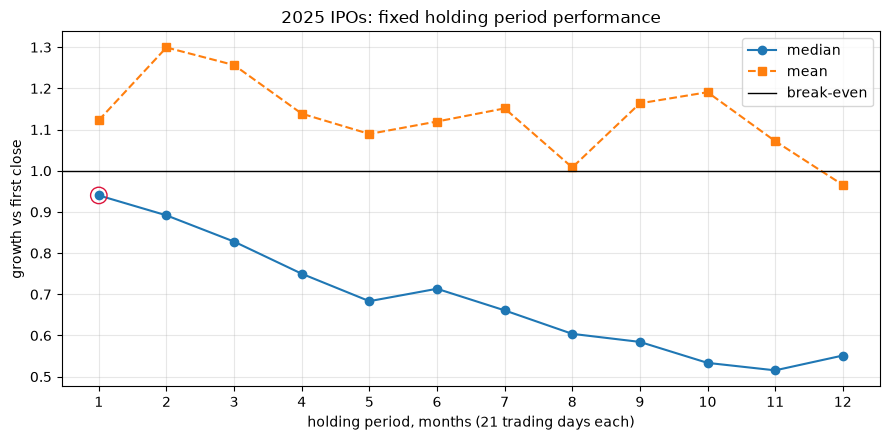

In [27]:
means = ipo_day_df[growth_cols].mean()
months = [int(c.split("_")[2]) for c in growth_cols]

plt.figure(figsize=(9, 4.5))
plt.plot(months, medians.values, marker="o", label="median")
plt.plot(months, means.values, marker="s", linestyle="--", label="mean")
plt.axhline(1.0, color="black", linewidth=1, label="break-even")
plt.scatter([q3_best_month], [q3_best_median], s=140, facecolors="none",
            edgecolors="crimson", zorder=5)
plt.xticks(months)
plt.xlabel("holding period, months (21 trading days each)")
plt.ylabel("growth vs first close")
plt.title("2025 IPOs: fixed holding period performance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the chart.** The median sits below 1.0 for essentially every horizon and drifts lower as the
holding period stretches - buying the first close and waiting is a losing trade for the *typical* IPO.
The mean stays well above the median because a few big winners carry the whole distribution; an investor
who buys IPOs indiscriminately is relying on catching one of those, not on a positive base rate.
Practically, the shortest horizons are the least bad, which argues for either fast exits or for
selecting IPOs on some signal rather than buying all of them.

---
## Question 4 - [Strategy] Simple RSI-based trading strategy

**Invest $1,000 every time RSI < 30 between 2000-01-01 and 2025-06-01 - what is the net income?**

The dataset is the precomputed parquet from the course (technical + macro indicators for a broad
ticker universe), so RSI does not need to be recomputed.

In [28]:
import gdown

FILE_ID = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "data.parquet", quiet=False)

df = pd.read_parquet("data.parquet", engine="pyarrow")
print("shape:", df.shape, "- a couple of hundred technical + macro indicator columns")

# The course dataset is the product of a merge, so the price column arrives as
# "Close_x" / "Close_y" rather than a plain "Close". Resolve it once here.
CLOSE_COL = next(c for c in ("Close", "Close_x", "Close_y") if c in df.columns)
PREVIEW = ["Date", "Ticker", CLOSE_COL, "rsi", "growth_future_30d"]

missing = [c for c in PREVIEW if c not in df.columns]
if missing:
    raise KeyError(f"expected columns absent from the parquet: {missing}")

print("close column:", repr(CLOSE_COL))
print("tickers:", df["Ticker"].nunique())
print("date range:", df["Date"].min(), "->", df["Date"].max())
df[PREVIEW].head()

Downloading...
From (original): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-
From (redirected): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-&confirm=t&uuid=4d9d8b0d-07f2-48e0-865b-0593c48d9b0b
To: /Users/dohg/Study/courses/aishippinglab/stock-markets-analytics-zoomcamp/homework/week2/data.parquet
100%|██████████| 130M/130M [00:34<00:00, 3.83MB/s] 


shape: (229932, 203) - a couple of hundred technical + macro indicator columns
close column: 'Close_x'
tickers: 33
date range: 1972-06-01 00:00:00 -> 2025-05-30 00:00:00


,Date,Ticker,Close_x,rsi,growth_future_30d
0,1986-03-13,MSFT,0.0596,NaN,0.9821
1,1986-03-14,MSFT,0.0617,NaN,0.9224
2,1986-03-17,MSFT,0.0628,NaN,0.8814
3,1986-03-18,MSFT,0.0612,NaN,0.9217
4,1986-03-19,MSFT,0.0601,NaN,0.9646


In [29]:
# Steps 2 + 3 - oversold signals inside the backtest window
RSI_THRESHOLD = 30
START_DATE, END_DATE = "2000-01-01", "2025-06-01"

df["Date"] = pd.to_datetime(df["Date"])
selected_df = df[
    (df["rsi"] < RSI_THRESHOLD)
    & (df["Date"] >= START_DATE)
    & (df["Date"] <= END_DATE)
].copy()

print(f"signals with RSI < {RSI_THRESHOLD}: {len(selected_df):,}  (homework mentions ~5,206)")
print(f"tickers involved: {selected_df['Ticker'].nunique()}")
selected_df[PREVIEW].head()

signals with RSI < 30: 5,206  (homework mentions ~5,206)
tickers involved: 33


,Date,Ticker,Close_x,rsi,growth_future_30d
3562,2000-04-14,MSFT,22.7195,28.5998,0.8988
3567,2000-04-24,MSFT,20.4207,28.1837,1.1023
3667,2000-09-14,MSFT,20.1717,28.7445,0.9753
3668,2000-09-15,MSFT,19.6736,24.7779,0.9854
3669,2000-09-18,MSFT,19.3097,22.3507,0.9722


In [30]:
# Step 4 - $1,000 per signal, exit after 30 days
INVESTMENT = 1000

trades = selected_df.dropna(subset=["growth_future_30d"])
net_income = INVESTMENT * (trades["growth_future_30d"] - 1).sum()

avg_return = trades["growth_future_30d"].mean() - 1
win_rate = (trades["growth_future_30d"] > 1).mean()
capital_deployed = INVESTMENT * len(trades)

print("ANSWER Q4")
print(f"  Net income : ${net_income:,.0f}  =  ${net_income/1000:,.1f}K  (~${net_income/1e6:,.2f}M)")
print()
print(f"  trades with a 30d outcome : {len(trades):,}")
print(f"  average 30-day return     : {avg_return*100:.2f}%   (homework mentions 1.26%)")
print(f"  win rate                  : {win_rate*100:.2f}%   (homework mentions 55.13%)")
print(f"  total capital deployed    : ${capital_deployed:,.0f}")
print(f"  return on deployed capital: {net_income/capital_deployed*100:.2f}%")

ANSWER Q4
  Net income : $65,806  =  $65.8K  (~$0.07M)

  trades with a 30d outcome : 5,206
  average 30-day return     : 1.26%   (homework mentions 1.26%)
  win rate                  : 55.13%   (homework mentions 55.13%)
  total capital deployed    : $5,206,000
  return on deployed capital: 1.26%


,trades,net_income,avg_return_pct,win_rate_pct
year,,,,
2000,213,"3,060.4622",1.4368,51.1737
2001,300,201.7201,0.0672,50.6667
2002,304,"6,244.8060",2.0542,56.5789
2003,263,"2,315.5587",0.8804,16.7300
2004,305,"11,492.7627",3.7681,37.0492
2005,136,"1,626.0211",1.1956,68.3824
2006,148,"3,979.4028",2.6888,66.2162
2007,111,639.2045,0.5759,49.5495
2008,453,"5,488.8113",1.2117,54.7461


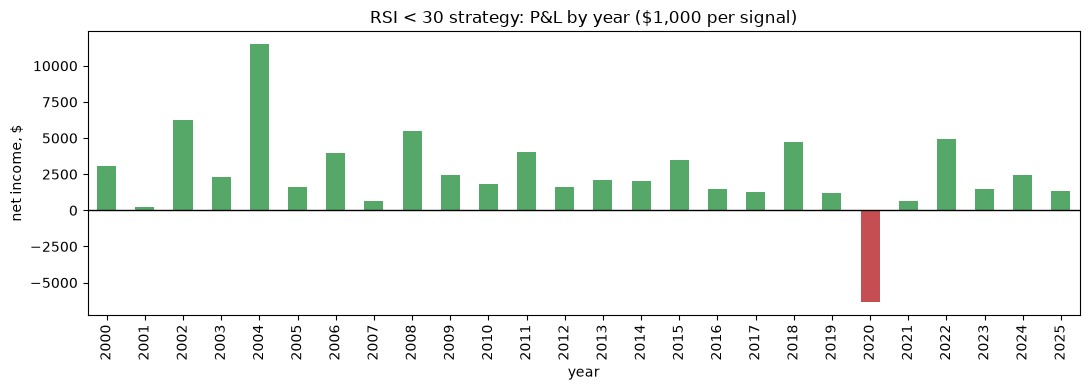

In [31]:
# Sanity check: does the edge hold over time, or does it come from one regime?
# (plain .agg rather than .apply(lambda ...): groupby.apply changed behaviour in pandas 3)
yearly = (
    trades.assign(year=trades["Date"].dt.year)
    .groupby("year")
    .agg(
        trades=("growth_future_30d", "size"),
        total_growth=("growth_future_30d", "sum"),
        avg_growth=("growth_future_30d", "mean"),
        wins=("growth_future_30d", lambda s: int((s > 1).sum())),
    )
)
yearly["net_income"] = INVESTMENT * (yearly["total_growth"] - yearly["trades"])
yearly["avg_return_pct"] = (yearly["avg_growth"] - 1) * 100
yearly["win_rate_pct"] = yearly["wins"] / yearly["trades"] * 100
yearly = yearly[["trades", "net_income", "avg_return_pct", "win_rate_pct"]]
display(yearly)

ax = yearly["net_income"].plot(
    kind="bar", figsize=(11, 4),
    color=np.where(yearly["net_income"] >= 0, "#55A868", "#C44E52"),
)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("net income, $")
ax.set_title(f"RSI < {RSI_THRESHOLD} strategy: P&L by year ($1,000 per signal)")
plt.tight_layout()
plt.show()

Caveats on the strategy: the $1,000-per-signal accounting ignores position overlap (many signals are open
at once, so the peak capital required is far above $1,000), transaction costs and slippage. It also uses a
fixed 30-day exit rather than a rule tied to RSI recovering above a threshold.

---
## Question 5 - [Exploratory] Predicting a positive-return IPO

Q2 and Q3 land in the same place: the median 2025 IPO loses money and even the 75th percentile is
unattractive. Buying every IPO is negative expectancy, so profitability has to come from **selection**,
**timing** or **structure** - not from broad exposure.

### 1. Select - don't buy the whole cohort

| Signal | Rationale | How to build it |
|---|---|---|
| Deal size / float | Tiny floats squeeze on day one, then bleed for months | `Shares x Offer price`; bucket into quintiles |
| Pricing vs filed range | Pricing *above* the range signals real institutional demand | `Offer price / Avg(Price Low, Price High)` |
| Sector | Biotech and SPACs behave nothing like profitable software | Industry column, one-hot |
| Underwriter tier | Bulge-bracket leads screen harder | Lead manager, grouped into tiers |
| Fundamentals at filing | Revenue growth, gross margin, path to profit | S-1 / `yfinance` financials |
| Lock-up expiry | Supply shock ~180 days after listing | Offer date + 180d, as a feature *and* an exit rule |

### 2. Time the entry

- **Skip day one.** The first close already contains the pop; Q3 shows it is mostly downhill afterwards.
- **Wait for the lock-up to clear**, then buy only names still above their IPO price - this filters out
  the structural sellers and keeps the momentum names.
- **Trade the quiet-period end** (~25 days), when sponsor analyst coverage initiates.

### 3. Change the payoff structure

- Long the top-decile names by the selection score, short an equal-weight IPO basket or an IPO ETF
  (`IPO`, `FPX`) to isolate selection skill from the cohort's negative drift.
- Size positions by volatility rather than equally - Q2 shows enormous dispersion in `volatility`.
- Hard stop-loss plus a trailing stop for winners: the return distribution is heavily right-skewed, so the
  strategy only works if the tail is allowed to run while losers are cut early.

### 4. Model it properly

Frame it as binary classification - `is_positive_growth_Nm_future` - on the features above, trained on
2015-2023 IPOs and validated *walk-forward* on 2024-2025. Points to watch:

- **Class balance:** positives are the minority; optimise precision at a chosen recall, not accuracy.
- **Survivorship bias:** delisted tickers (the ones Yahoo dropped in Q2) are the worst outcomes and must
  stay in the training set, marked as total losses.
- **Honest benchmark:** beating "buy every IPO" is easy; the real benchmark is SPY over the same window.
- **Sample size:** a few hundred IPOs a year means regularised, simple models (logistic regression,
  shallow trees) will generalise better than deep ones.

**Bottom line:** the edge in IPOs is not in participating - it is in declining most of them, entering after
the first-day and lock-up distortions clear, and sizing for a right-skewed payoff.

---
## Answer summary

Run this after executing everything above - these are the values to paste into the
[submission form](https://courses.datatalks.club/sma-zoomcamp-2026/homework/hw02).

In [32]:
print("=" * 62)
print("MODULE 2 HOMEWORK - ANSWERS")
print("=" * 62)
print(f"Q1  Company type            : {q1_type}")
print(f"    Total withdrawn value   : ${q1_value:,.1f}M")
print(f"Q2  Median Sharpe ({SNAPSHOT_DATE}): {q2_median_sharpe:.3f}")
print(f"Q3  Optimal holding period  : {q3_best_month} month(s), median growth {q3_best_median:.4f}")
print(f"Q4  Net income              : ${net_income/1000:,.1f}K")
print("Q5  See the write-up above (open-ended)")
print("=" * 62)

MODULE 2 HOMEWORK - ANSWERS
Q1  Company type            : Acquisition Corp
    Total withdrawn value   : $500.0M
Q2  Median Sharpe (2026-09-11): 0.048
Q3  Optimal holding period  : 1 month(s), median growth 0.9401
Q4  Net income              : $65.8K
Q5  See the write-up above (open-ended)
